# hw4 - NN pyTorch

Во всем задании вы должны работать со входом из строк размером (длиной) 1024

## Часть 1 Фурье

### Подготовка данных

Сгенерите данные (сигнал) любым пакетом для численного преобразования Фурье, [например](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)

In [54]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import signal
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

np.random.seed(17)
torch.manual_seed(17)

In [55]:
# Параметры
N = 1000
BATCH_SIZE = 32
SIGNAL_LENGTH = 1024
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Генерирует сигнал (сумма синусоид с разными частотами)
def generate_signal(length=SIGNAL_LENGTH, num_components=5):
    t = np.linspace(0, 1, length)
    signal = np.zeros(length)

    for _ in range(num_components):
        freq = np.random.uniform(1, 50)  # Частота
        amplitude = np.random.uniform(0.5, 2.0)  # Амплитуда
        phase = np.random.uniform(0, 2 * np.pi)  # Фаза
        signal += amplitude * np.sin(2 * np.pi * freq * t + phase)

    # Шум
    noise = np.random.normal(0, 0.1, length)
    signal += noise

    return signal.astype(np.float32)


X_train = np.array([generate_signal() for _ in range(N)])
y_train = np.array([np.fft.fft(x) for x in X_train])

y_train_real = y_train.real.astype(np.float32)  # Действительная часть
y_train_imag = y_train.imag.astype(np.float32)  # Мнимая часть

y_train_combined = np.stack([y_train_real, y_train_imag], axis=1)

print(f"Форма X_train: {X_train.shape}")
print(f"Форма y_train_combined: {y_train_combined.shape}")

Форма X_train: (1000, 1024)
Форма y_train_combined: (1000, 2, 1024)


### Соберите и обучите нейросетку на pyTroch для преобразования Фурье

In [56]:
# Обучаем модель
def train_model(
    model,
    data_loader,
    loss_function,
    optimizer,
    n_epochs,
    device,
):
    model.to(device)
    model.train()
    training_metrics = []

    for epoch in range(n_epochs):
        cumulative_loss = 0.0
        progress_indicator = tqdm(data_loader, desc=f"Эпоха {epoch+1}/{n_epochs}")

        for temporal_inputs, spectral_targets in progress_indicator:
            temporal_inputs = temporal_inputs.to(device)
            spectral_targets = spectral_targets.to(device)

            optimizer.zero_grad()

            predicted_spectra = model(temporal_inputs)

            optimization_loss = loss_function(predicted_spectra, spectral_targets)

            optimization_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            current_loss = optimization_loss.item()
            cumulative_loss += current_loss
            progress_indicator.set_postfix({"текущая ошибка": current_loss})

        average_epoch_loss = cumulative_loss / len(data_loader)
        training_metrics.append(average_epoch_loss)
        print(f"Средняя ошибка: {average_epoch_loss:.6f}")

    return training_metrics


Модель FourierTransformer:
Общее количество параметров: 39,884,800

Запуск процедуры обучения...


Эпоха 1/25: 100%|██████████| 32/32 [00:11<00:00,  2.72it/s, текущая ошибка=2.26e+3]


Средняя ошибка: 2202.720982


Эпоха 2/25: 100%|██████████| 32/32 [00:10<00:00,  2.92it/s, текущая ошибка=2.04e+3]


Средняя ошибка: 2128.540340


...

Средняя ошибка: 820.458673


Эпоха 24/25: 100%|██████████| 32/32 [00:10<00:00,  3.05it/s, текущая ошибка=827]


Средняя ошибка: 780.288181


Эпоха 25/25: 100%|██████████| 32/32 [00:11<00:00,  2.78it/s, текущая ошибка=884]

Средняя ошибка: 746.419264


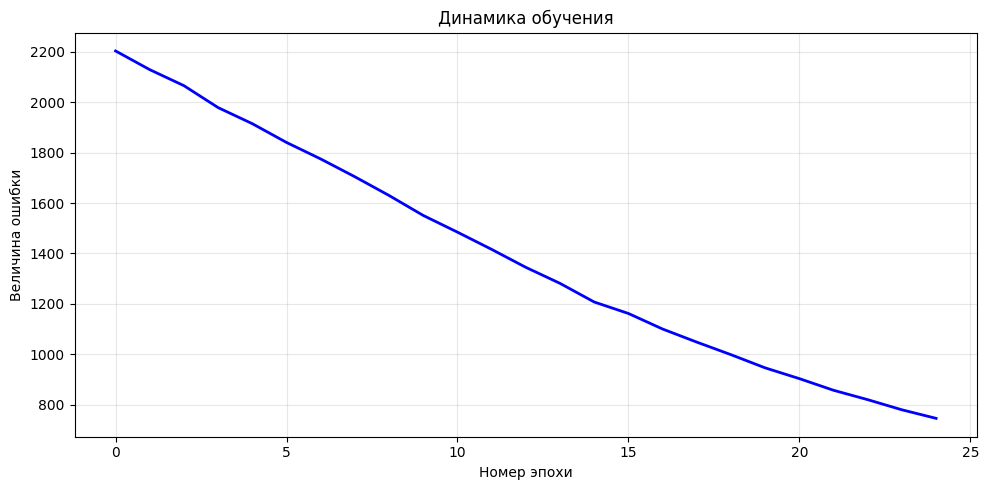


Финальная ошибка: 746.419264
Улучшение за обучение: 66.1%


In [57]:
class FourierTransformer(nn.Module):
    def __init__(self, input_size=SIGNAL_LENGTH, output_size=1024):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(2048),
            nn.Dropout(0.25),
            nn.Linear(2048, 4096),
            nn.ELU(),
            nn.BatchNorm1d(4096),
            nn.Dropout(0.25),
            nn.Linear(4096, 4096),
            nn.SiLU(),
            nn.BatchNorm1d(4096),
            nn.Dropout(0.25),
            nn.Linear(4096, 2048),
            nn.ReLU(),
            nn.BatchNorm1d(2048),
            nn.Dropout(0.25),
            nn.Linear(2048, 2 * output_size),
        )

    def forward(self, input_signal):
        spectral_output = self.feature_extractor(input_signal)
        batch_size = input_signal.size(0)
        return spectral_output.view(batch_size, 2, -1)


class FourierTrainingData:
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]


model = FourierTransformer().to(DEVICE)
training_dataset = FourierTrainingData(X_train, y_train_combined)
data_loader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)

loss_function = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

print(f"\nМодель FourierTransformer:")
print(
    f"Общее количество параметров: " f"{sum(p.numel() for p in model.parameters()):,}"
)
print("\nЗапуск процедуры обучения...")

TOTAL_TRAINING_EPOCHS = 25
performance_history = train_model(
    model,
    data_loader,
    loss_function,
    optimizer,
    TOTAL_TRAINING_EPOCHS,
    DEVICE,
)

plt.figure(figsize=(10, 5))

plt.plot(performance_history, "b-", linewidth=2)
plt.xlabel("Номер эпохи")
plt.ylabel("Величина ошибки")
plt.title("Динамика обучения")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nФинальная ошибка: {performance_history[-1]:.6f}")
print(
    f"Улучшение за обучение: "
    f"{(performance_history[0] - performance_history[-1])/performance_history[0]*100:.1f}%"
)

### Сравните свое решение с пакетным методом

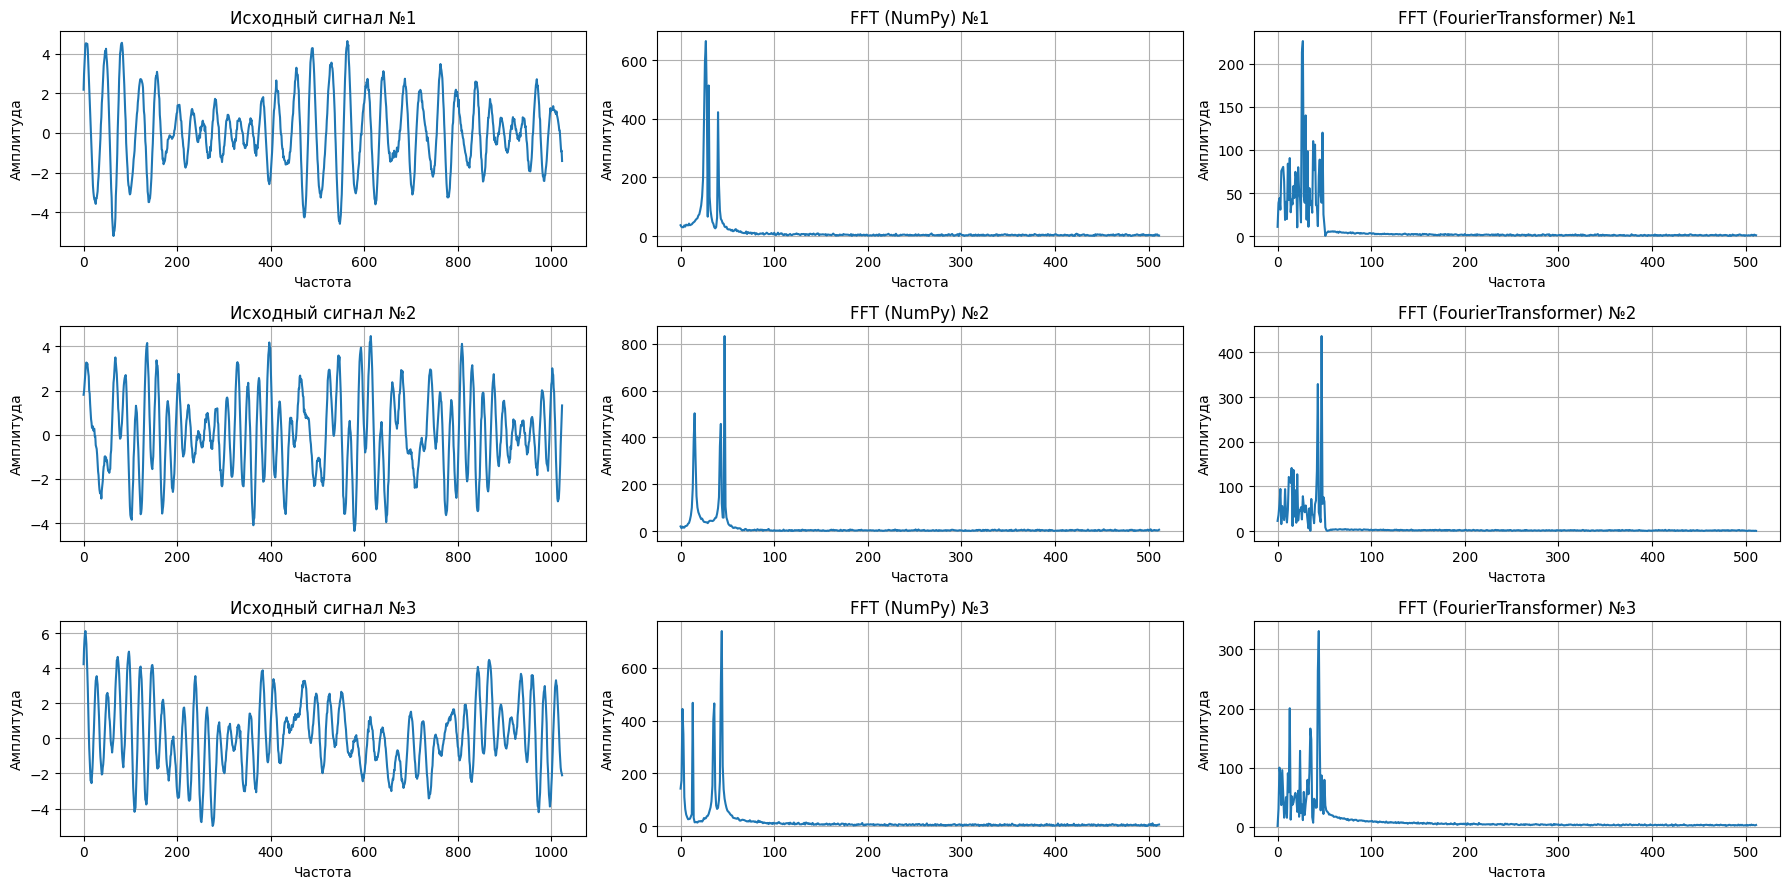


Сравнение FFT: NumPy vs FourierTransformer

Тестовый сигнал №1:
  MSE (действительная часть): 1336.2844
  MSE (мнимая часть): 993.3749
  MSE (амплитудный спектр): 2005.4790
  Корреляция (амплитудный спектр): 0.752409

Тестовый сигнал №2:
  MSE (действительная часть): 554.7128
  MSE (мнимая часть): 882.4514
  MSE (амплитудный спектр): 1152.1901
  Корреляция (амплитудный спектр): 0.875253

Тестовый сигнал №3:
  MSE (действительная часть): 1145.3730
  MSE (мнимая часть): 825.9620
  MSE (амплитудный спектр): 1564.2640
  Корреляция (амплитудный спектр): 0.890021

Средние метрики:
  Средний MSE (действительная часть): 1012.1234
  Средний MSE (мнимая часть): 900.5960
  Средняя корреляция (амплитудный спектр): 0.839227


In [58]:
# Сравним на 3 сгенерированных сигналах
n_test = 3
test_signals = np.array([generate_signal() for _ in range(n_test)])

model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(test_signals, dtype=torch.float32).to(DEVICE)
    predictions = model(test_tensor).cpu().numpy()

# Вычисляем FFT с помощью Numpy
fft_numpy = np.array([np.fft.fft(sig) for sig in test_signals])

fig, axes = plt.subplots(n_test, 3, figsize=(18, 3 * n_test))

for i in range(n_test):
    # Амплитудный спектр от Numpy FFT
    fft_magnitude_numpy = np.abs(fft_numpy[i])

    # Амплитудный спектр от FourierTransformer
    fft_nn = predictions[i][0] + 1j * predictions[i][1]
    fft_magnitude_nn = np.abs(fft_nn)

    axes[i, 0].plot(test_signals[i])
    axes[i, 0].set_title(f"Исходный сигнал №{i+1}")
    axes[i, 0].set_xlabel("Частота")
    axes[i, 0].set_ylabel("Амплитуда")
    axes[i, 0].grid(True)

    axes[i, 1].plot(fft_magnitude_numpy[: SIGNAL_LENGTH // 2])
    axes[i, 1].set_title(f"FFT (NumPy) №{i+1}")
    axes[i, 1].set_xlabel("Частота")
    axes[i, 1].set_ylabel("Амплитуда")
    axes[i, 1].grid(True)

    axes[i, 2].plot(fft_magnitude_nn[: SIGNAL_LENGTH // 2])
    axes[i, 2].set_title(f"FFT (FourierTransformer) №{i+1}")
    axes[i, 2].set_xlabel("Частота")
    axes[i, 2].set_ylabel("Амплитуда")
    axes[i, 2].grid(True)

plt.tight_layout()
plt.show()

print("\nСравнение FFT: NumPy vs FourierTransformer\n")
for i in range(n_test):
    fft_nn = predictions[i][0] + 1j * predictions[i][1]

    # MSE между действительными частями
    mse_real = np.mean((fft_numpy[i].real - predictions[i][0]) ** 2)

    # MSE между мнимыми частями
    mse_imag = np.mean((fft_numpy[i].imag - predictions[i][1]) ** 2)

    # MSE для амплитудных спектров
    mse_magnitude = np.mean((np.abs(fft_numpy[i]) - np.abs(fft_nn)) ** 2)

    # Корреляция между амплитудными спектрами
    correlation = np.corrcoef(np.abs(fft_numpy[i]), np.abs(fft_nn))[0, 1]

    print(f"Тестовый сигнал №{i+1}:")
    print(f"  MSE (действительная часть): {mse_real:.4f}")
    print(f"  MSE (мнимая часть): {mse_imag:.4f}")
    print(f"  MSE (амплитудный спектр): {mse_magnitude:.4f}")
    print(f"  Корреляция (амплитудный спектр): {correlation:.6f}")
    print()

# Среднее по всем тестовым сигналам
avg_mse_real = np.mean(
    [np.mean((fft_numpy[i].real - predictions[i][0]) ** 2) for i in range(n_test)]
)
avg_mse_imag = np.mean(
    [np.mean((fft_numpy[i].imag - predictions[i][1]) ** 2) for i in range(n_test)]
)
avg_correlation = np.mean(
    [
        np.corrcoef(
            np.abs(fft_numpy[i]), np.abs(predictions[i][0] + 1j * predictions[i][1])
        )[0, 1]
        for i in range(n_test)
    ]
)

print(f"Средние метрики:")
print(f"  Средний MSE (действительная часть): {avg_mse_real:.4f}")
print(f"  Средний MSE (мнимая часть): {avg_mse_imag:.4f}")
print(f"  Средняя корреляция (амплитудный спектр): {avg_correlation:.6f}")

## Часть 2 Power spectral density (dB)

### Подготовка данных

Используя пакетное решение, [например](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html), подготовьте обучающую выборку.

### Соберите и обучите нейросеть для предсказания спектральной плотности мощности

*Подсказка: для входа 1024 выход будет 512*

### Провалидируйте свое решение

*Примечание: Для сдачи достаточно качественного соответствия по форме спектра с пакетным решением*